![](https://media.giphy.com/media/3o6MbrACMlFCny8zmw/giphy.gif)

Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

# Question 1

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a line graph of total population over time for the states: NY, PA, CT, NJ (10 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Specify colors to be used in your code. (5 pts)

# Question 2

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a Bar Graph of the total population for 5 cities in the state of New York comparing 2014 years and 2018 years (15 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Combine the graph in question 1 and question 2 in one figure.

## Question 3

import the data "job-automation-probability.csv"
1. A Histogram of the variable 'probability'
2. A scatter plot of 'Average annual wage' and 'numbEmployed'
3. Put both of these graphs in one figure
4. Using item 3, change the ticks of Number Employed axes so that it is in logarithmic axis (hint: it's an option) 
5. Adding onto item 4, add a title and axis labels
6. Save your figure as a png

In [1]:
#load packages
import pandas as pd
import matplotlib.pyplot as plt

#load data
path = r"C:\Users\iakov\OneDrive\Desktop\ECO590\weekly-task-5-Iakovos2t\weekly task 5\\"
cities = pd.read_csv(path+"us-cities-top-1k-multi-year.csv")
jobs = pd.read_csv(path+"job-automation-probability.csv")

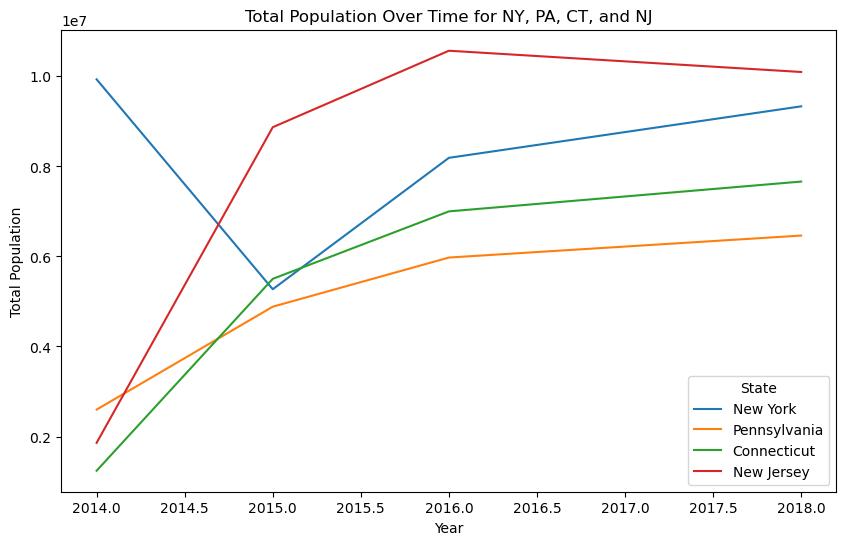

In [2]:
#pick the states we need
states = ["New York", "Pennsylvania", "Connecticut", "New Jersey"]

#keep only those states
q1 = cities[cities["State"].isin(states)]

#sum population by year and state
state_pop = q1.groupby(["year", "State"])["Population"].sum().unstack()

#create figure
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(10,6))

#make line graph
ax1.plot(state_pop.index, state_pop["New York"], label="New York")
ax1.plot(state_pop.index, state_pop["Pennsylvania"], label="Pennsylvania")
ax1.plot(state_pop.index, state_pop["Connecticut"], label="Connecticut")
ax1.plot(state_pop.index, state_pop["New Jersey"], label="New Jersey")

#labels and title
ax1.set_title("Total Population Over Time for NY, PA, CT, and NJ")
ax1.set_xlabel("Year")
ax1.set_ylabel("Total Population")
ax1.legend(title="State")

plt.show()

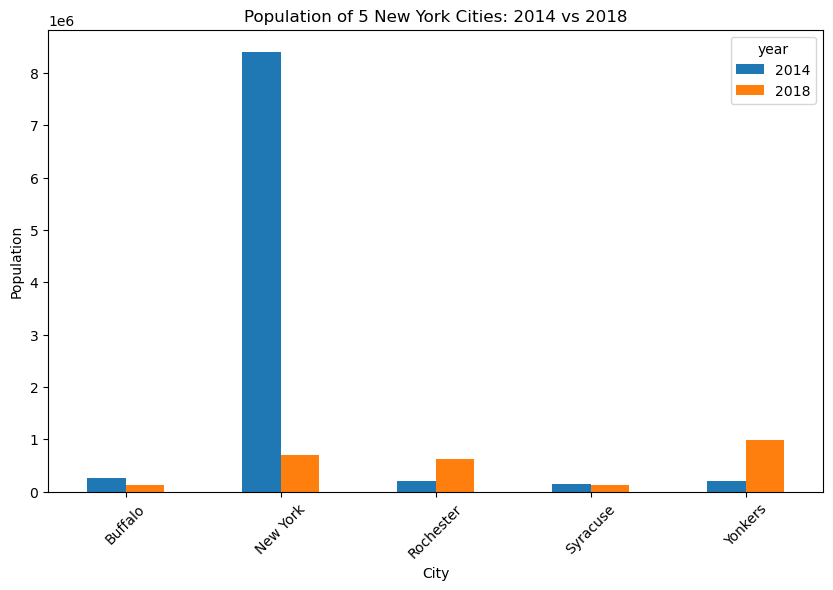

In [4]:
#pick 5 ny cities
ny_cities = ["New York", "Buffalo", "Rochester", "Yonkers", "Syracuse"]

#keep only ny, those 5 cities, and years 2014 and 2018
q2 = cities[(cities["State"] == "New York") & 
            (cities["City"].isin(ny_cities)) & 
            (cities["year"].isin([2014, 2018]))]
#reshape data for graph
city_pop = q2.pivot(index="City", columns="year", values="Population")

#make bar graph
city_pop.plot(kind="bar", figsize=(10,6))

#labels and title
plt.title("Population of 5 New York Cities: 2014 vs 2018")
plt.xlabel("City")
plt.ylabel("Population")
plt.xticks(rotation=45)
plt.show()

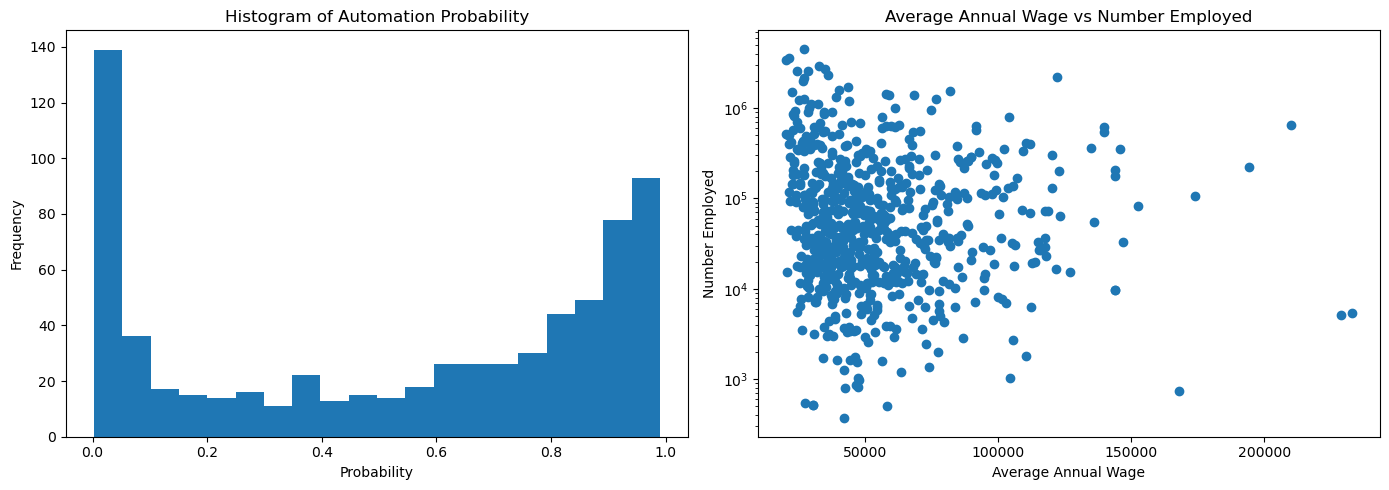

In [5]:
#make one figure with 2 graphs
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14,5))

#histogram of automation probability
ax1 = plt.subplot(1, 2, 1)
ax1.hist(jobs["probability"], bins=20)
ax1.set_title("Histogram of Automation Probability")
ax1.set_xlabel("Probability")
ax1.set_ylabel("Frequency")

#scatter plot of wage and employed
ax2 = plt.subplot(1, 2, 2)
ax2.scatter(jobs["Average annual wage"], jobs["numbEmployed"])
ax2.set_title("Average Annual Wage vs Number Employed")
ax2.set_xlabel("Average Annual Wage")
ax2.set_ylabel("Number Employed")
ax2.set_yscale("log")

#make layout cleaner
plt.tight_layout()

#save figure as png
plt.savefig("weekly_task_5_q3.png", dpi=300, bbox_inches="tight")

plt.show()